# Machine Learning Model Evaluation Pipeline

## 1. Importing Required Libraries
- **Pandas, NumPy**: Data manipulation and numerical operations.
- **Pickle**: Load preprocessed dataset.
- **Scikit-Learn**: Train-test split, model training, evaluation metrics, and cross-validation.
- **Seaborn & Matplotlib**: Data visualization.

In [239]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

## **2. Loading Preprocessed Data**
- Data is loaded from a pickle file (`processed_data.pkl`).
- Splitting Features (`X`) and Target (`y`).

In [240]:
with open("processed_data.pkl", "rb") as file:
    final_df = pickle.load(file)

X = final_df.drop(columns=['disease_type'])
y = final_df['disease_type']

## 3. Train-Test Splitting
- 80% Training, 20% Testing.
- Stratified sampling ensures balanced class distribution.

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Cross-Validation Function
- Performs k-fold (default: 5) cross-validation.
- Returns mean and standard deviation of accuracy.

In [242]:
def cross_validate_model(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return scores.mean(), scores.std()

## 5. Model Training & Evaluation Function
- Trains the model on training data.
- Evaluates performance using accuracy, precision, recall, and F1-score.
- Displays confusion matrix for error analysis.
- Performs cross-validation for robustness.

In [243]:
def train_and_evaluate_model(model, name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred, average='weighted')
    recall = recall_score(y_test, test_pred, average='weighted')
    f1 = f1_score(y_test, test_pred, average='weighted')
    
    cv_mean, cv_std = cross_validate_model(model, X_train, y_train)
    
    print(f"{name} -> Training Accuracy: {train_acc:.4f}, Testing Accuracy: {test_acc:.4f}, Cross-Validation Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
    print(f"Classification Report for {name} (Testing Data):\n{classification_report(y_test, test_pred)}")
    
    # Confusion Matrix Visualization
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    
    return train_acc, test_acc, model


## 6. Defining Machine Learning Models
- Random Forest (200 trees, max depth 13)
- Support Vector Machine (Linear Kernel)
- Logistic Regression (LBFGS solver)
- Decision Tree (Depth 14, min samples 9)

In [244]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_split=5, min_samples_leaf=2,random_state=42),
    "SVM": SVC(kernel='linear', C=1.0, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=14, min_samples_split=9, min_samples_leaf=3, random_state=42)
}

## 7. Model Training and Selection
- Trains all models and stores their accuracy scores.
- Tracks the best-performing model.

Random Forest -> Training Accuracy: 0.9850, Testing Accuracy: 0.9457, Cross-Validation Accuracy: 0.9414 ± 0.0116
Precision: 0.9476, Recall: 0.9457, F1-Score: 0.9451
Classification Report for Random Forest (Testing Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.75      0.83      0.79        18
           2       1.00      1.00      1.00        18
           3       0.94      0.89      0.91        18
           4       0.84      0.84      0.84        19
           5       0.82      0.78      0.80        18
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        19
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.81      0.94      0.87        18
          12       0.93      0.68      0.79        19
          13       1.0

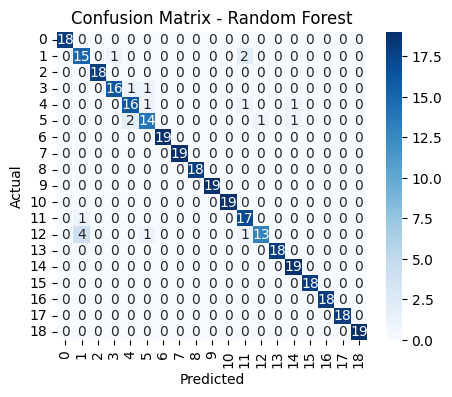

SVM -> Training Accuracy: 0.9170, Testing Accuracy: 0.8857, Cross-Validation Accuracy: 0.8870 ± 0.0087
Precision: 0.8888, Recall: 0.8857, F1-Score: 0.8830
Classification Report for SVM (Testing Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.68      0.72      0.70        18
           2       1.00      1.00      1.00        18
           3       0.64      0.89      0.74        18
           4       0.67      0.42      0.52        19
           5       0.61      0.61      0.61        18
           6       1.00      0.95      0.97        19
           7       0.95      1.00      0.97        19
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.65      0.61      0.63        18
          12       0.93      0.68      0.79        19
          13       1.00      1.00      1.0

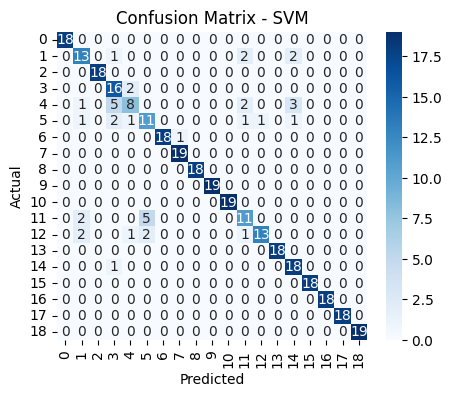

Logistic Regression -> Training Accuracy: 0.8884, Testing Accuracy: 0.8571, Cross-Validation Accuracy: 0.8648 ± 0.0146
Precision: 0.8575, Recall: 0.8571, F1-Score: 0.8557
Classification Report for Logistic Regression (Testing Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.63      0.67      0.65        18
           2       1.00      1.00      1.00        18
           3       0.74      0.78      0.76        18
           4       0.38      0.32      0.34        19
           5       0.58      0.61      0.59        18
           6       1.00      0.89      0.94        19
           7       0.95      1.00      0.97        19
           8       0.95      1.00      0.97        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.62      0.72      0.67        18
          12       0.86      0.63      0.73        19
          

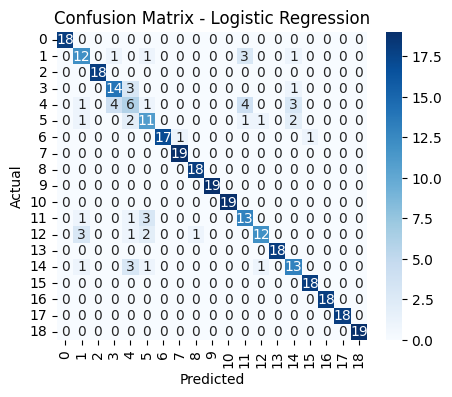

Decision Tree -> Training Accuracy: 0.9571, Testing Accuracy: 0.9000, Cross-Validation Accuracy: 0.9099 ± 0.0093
Precision: 0.9062, Recall: 0.9000, F1-Score: 0.9002
Classification Report for Decision Tree (Testing Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.87      0.72      0.79        18
           2       1.00      1.00      1.00        18
           3       0.68      0.83      0.75        18
           4       0.71      0.63      0.67        19
           5       0.70      0.89      0.78        18
           6       1.00      0.89      0.94        19
           7       0.95      1.00      0.97        19
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.73      0.61      0.67        18
          12       0.65      0.79      0.71        19
          13       1.0

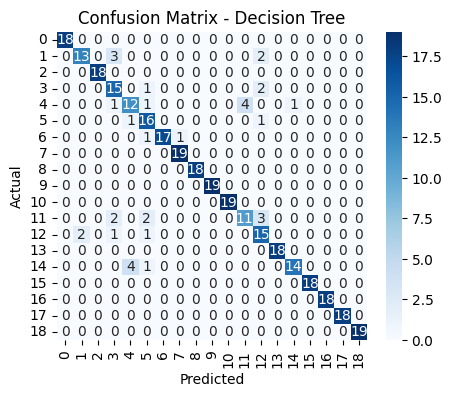

In [245]:
best_model = None
best_accuracy = 0
best_model_name = ""
model_accuracies = {}
training_accuracies = {}
cv_accuracies = {}

for name, model in models.items():
    train_acc, test_acc, trained_model = train_and_evaluate_model(model, name)
    model_accuracies[name] = test_acc
    training_accuracies[name] = train_acc
    cv_accuracies[name] = cross_validate_model(model, X_train, y_train)[0]
    
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model = trained_model
        best_model_name = name

## 9. Saving the Best Model
- Stores the highest-accuracy model as best_model.pkl.

In [246]:
with open("best_model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)

print(f"Best trained model saved as 'best_model.pkl'")

Best trained model saved as 'best_model.pkl'


## 10. Visualizing Model Performance
- Model Testing Accuracy Comparison
- Plots accuracy of different models.

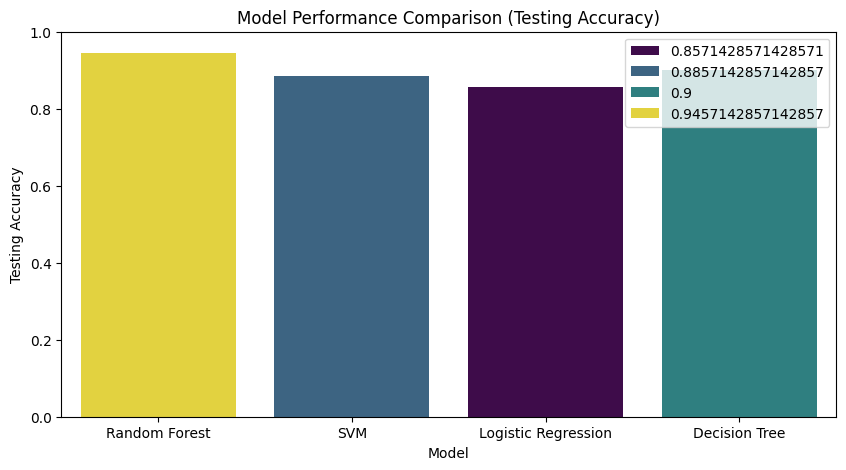

In [247]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()),hue=list(model_accuracies.values()), palette="viridis")
plt.xlabel("Model")
plt.ylabel("Testing Accuracy")
plt.title("Model Performance Comparison (Testing Accuracy)")
plt.ylim(0, 1)
plt.show()

## 11. Training vs Testing Accuracy Comparison
- Shows if models are overfitting.

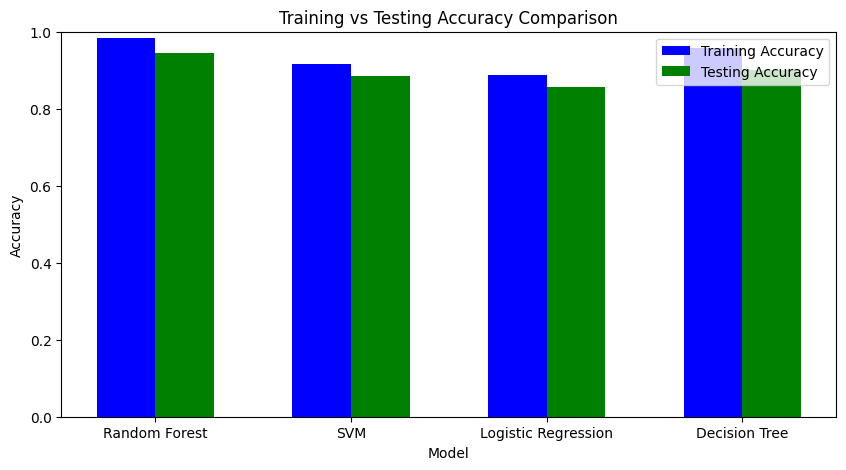

In [248]:
plt.figure(figsize=(10, 5))
x_labels = list(model_accuracies.keys())
x = np.arange(len(x_labels))
width = 0.3

plt.bar(x - width/2, training_accuracies.values(), width=width, label="Training Accuracy", color='blue')
plt.bar(x + width/2, model_accuracies.values(), width=width, label="Testing Accuracy", color='green')
plt.xticks(ticks=x, labels=x_labels)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.ylim(0, 1)
plt.show()